# Logistic Regression

## Importing the libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Importing the dataset

In [69]:
dt = pd.read_csv('maintenance_cleaned.csv')

## Analyse

In [70]:
display(dt.head())
display(dt.describe())
display(dt.info())

,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,failure_within_24h
0,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,0
1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,0
2,CNC,0.71,49.70,6.43,21.3,862.7,idle,274.15,13.6,0
3,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,0
4,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,0


,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,failure_within_24h
count,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000
mean,1.605370,51.357662,8.751044,58.523667,1138.445662,172.630624,12.996398,0.148074
std,1.041905,12.302671,5.300137,38.050389,903.498629,150.722469,2.883994,0.355181
min,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.000000
25%,0.850000,42.890000,4.710000,23.100000,496.025000,42.870000,10.500000,0.000000
50%,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,0.000000
75%,2.230000,59.600000,12.990000,90.800000,1667.875000,295.575000,15.500000,0.000000
max,6.370000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   machine_type             24042 non-null  object 
 1   vibration_rms            24042 non-null  float64
 2   temperature_motor        24042 non-null  float64
 3   current_phase_avg        24042 non-null  float64
 4   pressure_level           24042 non-null  float64
 5   rpm                      24042 non-null  float64
 6   operating_mode           24042 non-null  object 
 7   hours_since_maintenance  24042 non-null  float64
 8   ambient_temp             24042 non-null  float64
 9   failure_within_24h       24042 non-null  int64  
dtypes: float64(7), int64(1), object(2)
memory usage: 1.8+ MB


None

## Splitting the dataset into the Training set and Test set

In [71]:
# On sépare les données prédictives (caractéristiques techniques) de la donnée à prédire (failure_within_24h).
X = dt[[
    "machine_type",
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm",
    "operating_mode",
    "hours_since_maintenance",
    "ambient_temp"
]].values

y = dt["failure_within_24h"].values

In [72]:
"""
On divise le jeu de données de maintenance en deux :
- un groupe d'entraînement pour le modèle
- un groupe de test pour évaluer la capacité à prédire les pannes.
"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 101)

X_train = pd.DataFrame(X_train)

In [73]:
display(X_train)

,0,1,2,3,4,5,6,7,8
0,Robotic Arm,0.89,36.85,5.77,39.4,340.1,normal,81.33,17.3
1,Robotic Arm,0.88,42.29,5.56,39.2,365.8,normal,202.03,10.8
2,Compressor,3.21,62.88,22.93,160.3,2476.1,peak,343.18,16.9
3,Robotic Arm,0.87,35.23,5.95,41.7,358.6,normal,178.27,12.6
4,Compressor,2.53,64.59,13.74,96.2,1718.5,normal,477.66,10.1
...,...,...,...,...,...,...,...,...,...
16103,CNC,2.05,56.97,13.71,75.1,2821.2,normal,164.6,14.5
16104,Pump,0.67,58.53,3.94,20.9,505.5,idle,53.15,13.5
16105,Compressor,1.41,53.59,6.42,55.9,664.7,idle,25.0,17.5
16106,Compressor,0.94,49.83,5.9,43.7,746.5,idle,41.87,10.1


In [74]:
print(y_train)

[0 0 0 ... 1 0 0]


In [75]:
print(X_test)

[['Robotic Arm' 1.63 66.95 ... 'normal' 154.47 14.2]
 ['Compressor' 2.79 54.66 ... 'normal' 10.27 8.7]
 ['Robotic Arm' 0.5 51.71 ... 'idle' 142.07 13.5]
 ...
 ['CNC' 0.92 55.18 ... 'idle' 193.81 12.2]
 ['Pump' 0.64 35.75 ... 'idle' 137.08 8.9]
 ['Pump' 1.91 59.75 ... 'normal' 158.11 15.7]]


In [76]:
print(y_test)

[1 0 1 ... 1 0 0]


## Feature Scaling

In [77]:
"""
On transforme les variables catégorielles (strings) en nombres via OneHotEncoding,
puis on met toutes les variables à la même échelle avec StandardScaler.
"""
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Définition des colonnes numériques et catégorielles
# X_train est actuellement un DataFrame (id: fsMS0Ot5vwxX)
numerical_cols = [1, 2, 3, 4, 5, 7, 8] # vibration, temp, current, pressure, rpm, hours, ambient
categorical_cols = [0, 6]            # machine_type, operating_mode

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

# Transformation des sets d'entraînement et de test
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Note: sc est maintenant remplacé par preprocessor pour les transformations futures
sc = preprocessor

In [78]:
print(X_train)

[[-0.68077158 -1.16668384 -0.55421252 ...  0.          1.
   0.        ]
 [-0.6903722  -0.72498775 -0.59369441 ...  0.          1.
   0.        ]
 [ 1.54657073  0.94679946  2.6720224  ...  0.          0.
   1.        ]
 ...
 [-0.18153968  0.19250596 -0.43200665 ...  1.          0.
   0.        ]
 [-0.63276851 -0.11278398 -0.52977134 ...  1.          0.
   0.        ]
 [-0.58476545 -0.46597847 -0.32672159 ...  1.          0.
   0.        ]]


In [79]:
print(X_test)

[[ 0.02967381  1.27725958 -0.11615148 ...  0.          1.
   0.        ]
 [ 1.14334497  0.27938368  1.08898638 ...  0.          1.
   0.        ]
 [-1.0551955   0.03986099 -1.04679617 ...  1.          0.
   0.        ]
 ...
 [-0.65196974  0.32160463 -0.16691392 ...  1.          0.
   0.        ]
 [-0.92078692 -1.25599739 -0.99979391 ...  1.          0.
   0.        ]
 [ 0.29849099  0.69266182  1.61541166 ...  0.          1.
   0.        ]]


## Training the Logistic Regression model on the Training set

In [80]:
"""
On crée et on paramètre le modèle.
Ensuite, on entraîne le modèle pour prédire si une machine va tomber en panne ou non grâce à la méthode fit().
"""
from sklearn.linear_model import LogisticRegression

# Initialisation du modèle de Régression Logistique
classifier = LogisticRegression(random_state=0)

# Entraînement sur le Training set
classifier.fit(X_train, y_train)

# Affichage de la configuration
print(classifier)

LogisticRegression(random_state=0)


## Predicting a new result

In [81]:
"""
On prédit si une machine spécifique va tomber en panne.
On doit fournir les 9 caractéristiques dans le bon ordre :
[machine_type, vibration_rms, temperature_motor, current_phase_avg,
 pressure_level, rpm, operating_mode, hours_since_maintenance, ambient_temp]
"""
# Note : On utilise 'idle' car 'heavy_load' n'est pas présent dans les données d'entraînement.
new_prediction = classifier.predict(sc.transform([['CNC', 0.8, 50.0, 5.0, 10.0, 1500.0, 'idle', 500.0, 25.0]]))

print(f"Prédiction de panne (1=Oui, 0=Non) : {new_prediction[0]}")

Prédiction de panne (1=Oui, 0=Non) : 0


## Predicting the Test set results

In [82]:
"""
On prédit les résultats sur les données de test.
On affiche ensuite les prédictions (colonne 1) à côté des vraies valeurs (colonne 2).
- 1 : Panne prévue / réelle
- 0 : Fonctionnement normal prévu / réel
"""
testSetPred = classifier.predict(X_test)

# Affichage des 15 premières lignes pour comparaison
comparison = np.concatenate((testSetPred.reshape(len(testSetPred),1), y_test.reshape(len(y_test),1)),1)
print("Prédiction | Réalité")
print(comparison[:15])

Prédiction | Réalité
[[1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]]


## Making the Confusion Matrix

In [83]:
# L'accuracy est d'environ 0.93, ce qui signifie que le modèle prédit correctement les pannes dans 93% des cas sur ce jeu de données de maintenance.
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Calcul et affichage de la matrice de confusion
# On compare les pannes réelles (y_test) avec les prédictions (testSetPred)
cm = confusion_matrix(y_test, testSetPred)
print(cm)

# 2. Calcul et affichage du score de précision (Accuracy)
accuracy = accuracy_score(y_test, testSetPred)
print(accuracy)

[[6549  188]
 [ 377  820]]
0.9287874968490043


## Visualising the Training set results

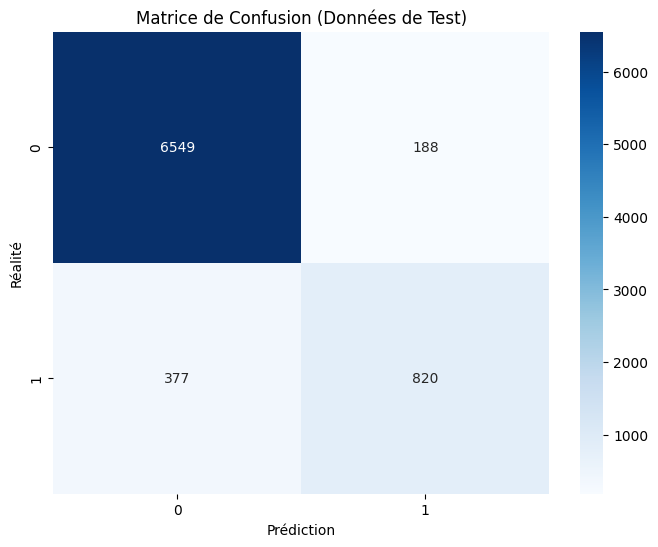

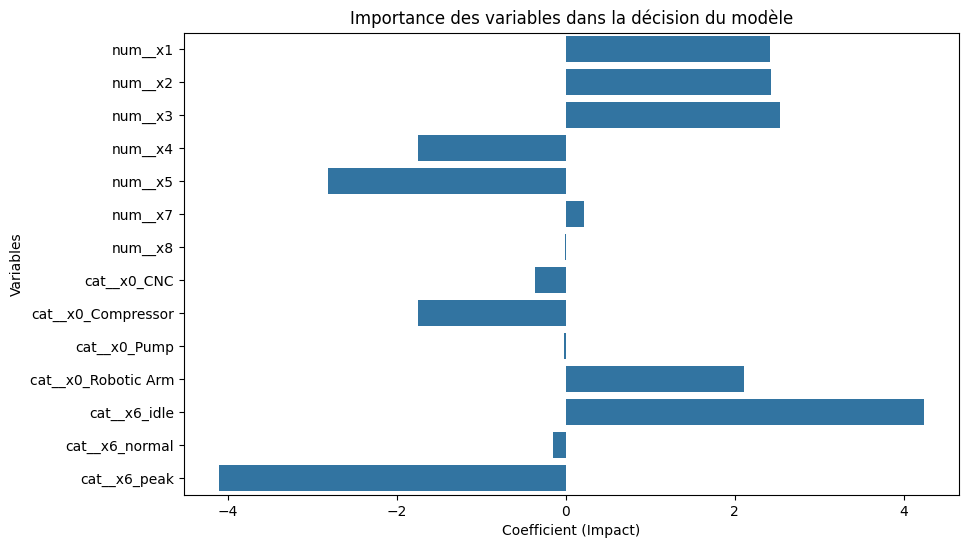

In [84]:
"""
Visualisation de la performance du modèle.
Comme nous avons 9 variables, nous ne pouvons plus faire de graphique 2D simple.
On affiche la matrice de confusion et l'importance des variables.
"""
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Matrice de Confusion sous forme de Heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, testSetPred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion (Données de Test)')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.show()

# 2. Importance des caractéristiques (Coefficients de la Régression)
# Note: On récupère les noms des colonnes après transformation
feature_names = preprocessor.get_feature_names_out()
coefficients = classifier.coef_[0]

plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients, y=feature_names)
plt.title('Importance des variables dans la décision du modèle')
plt.xlabel('Coefficient (Impact)')
plt.ylabel('Variables')
plt.show()

## Visualising the Test set results

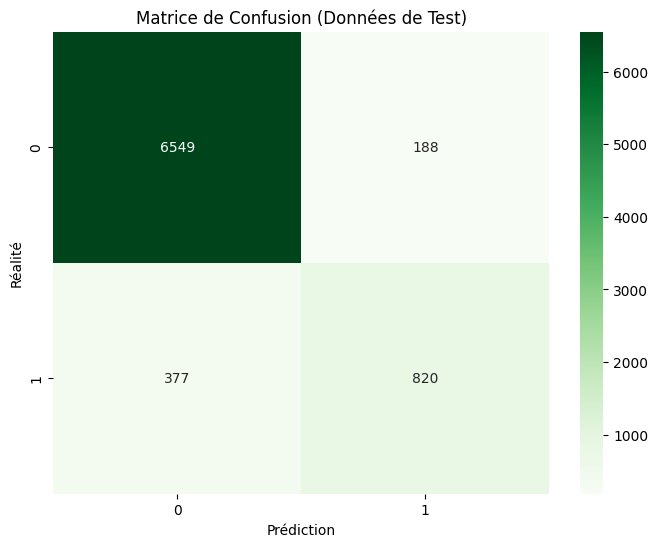

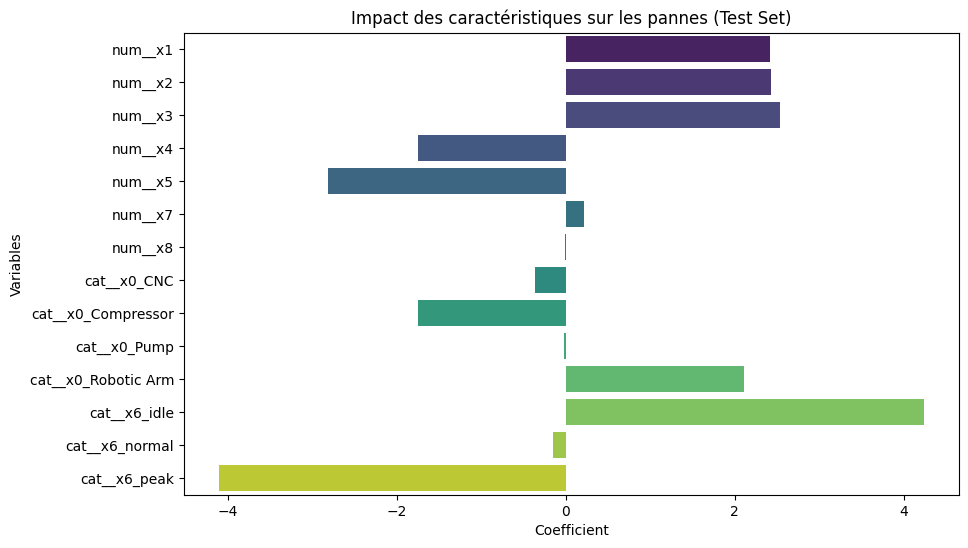

In [85]:
"""
Visualisation de la performance sur le set de Test.
On utilise une matrice de confusion et l'importance des variables pour valider le modèle.
"""
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Matrice de Confusion (Test Set)
plt.figure(figsize=(8, 6))
cm_test = confusion_matrix(y_test, testSetPred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens')
plt.title('Matrice de Confusion (Données de Test)')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.show()

# 2. Importance des variables (Coefficients)
feature_names = preprocessor.get_feature_names_out()
coefficients = classifier.coef_[0]

plt.figure(figsize=(10, 6))
# Correction du warning: assignation de 'hue' et suppression de la légende inutile
sns.barplot(x=coefficients, y=feature_names, hue=feature_names, palette='viridis', legend=False)
plt.title('Impact des caractéristiques sur les pannes (Test Set)')
plt.xlabel('Coefficient')
plt.ylabel('Variables')
plt.show()

## Exporting the model
To use this model elsewhere, we save the classifier and the preprocessor.

In [86]:
import pickle

# Sauvegarde du modèle
with open('logistic_regression_model.pkl', 'wb') as model_file:
    pickle.dump(classifier, model_file)

# Sauvegarde du préprocesseur (crucial pour traiter les nouvelles données de la même manière)
with open('preprocessor.pkl', 'wb') as preprocessor_file:
    pickle.dump(sc, preprocessor_file)

print("Modèle et préprocesseur exportés avec succès !")

Modèle et préprocesseur exportés avec succès !


In [87]:
import pickle
# Load
model = pickle.load(open('logistic_regression_model.pkl', 'rb'))
prep = pickle.load(open('preprocessor.pkl', 'rb'))
# Predict
result = model.predict(prep.transform([['CNC', 0.8, 50, 5, 10, 1500, 'idle', 500, 25]]))

print(result)

[0]
